In [11]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch import Tensor
import matplotlib.pyplot as plt

### 데이터 불러오기

In [12]:
loaded_data = np.loadtxt('../data/pima_indians_diabetes/diabetes_train.csv', delimiter=',', skiprows=1)

x_train_np = loaded_data[:, 1:-1]
y_train_np = loaded_data[:, [-1]]

In [13]:
print('loaded_data.shape = ', loaded_data.shape)
print('x_train_np.shape = ', x_train_np.shape)
print('y_train_np.shape = ', y_train_np.shape)

loaded_data.shape =  (576, 10)
x_train_np.shape =  (576, 8)
y_train_np.shape =  (576, 1)


### 데이터셋 선언

In [14]:
x_train = torch.Tensor(x_train_np)
y_train = torch.Tensor(y_train_np)

class CustomDataset(Dataset):
    
    def __init__(self, x_train, y_train) -> None:
        self.x_train:Tensor = x_train
        self.y_train:Tensor = y_train
        
    def __getitem__(self, index):
        return self.x_train[index], self.y_train[index]
    
    def __len__(self):
        return self.x_train.shape[0]

dataset = CustomDataset(x_train, y_train)

In [15]:
train_loader = DataLoader(dataset=dataset, batch_size=64, shuffle=True)

### 모델 선언

In [16]:
class MyLogisticRegressionModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        
        self.logistic_stack = nn.Sequential(
            nn.Linear(8, 8),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
        
    def forward(self, data):
        pred = self.logistic_stack(data)
        
        return pred

In [17]:
model = MyLogisticRegressionModel()

for param in model.parameters():
    print(param)

Parameter containing:
tensor([[ 0.3094,  0.1199, -0.1328, -0.1801,  0.2499,  0.2069,  0.3307, -0.0522],
        [ 0.0295,  0.0162,  0.1152,  0.0465,  0.1353,  0.3134,  0.0508, -0.2960],
        [ 0.1842,  0.2240,  0.2283, -0.3482,  0.1064, -0.0795, -0.3519,  0.1093],
        [-0.2232, -0.2879,  0.1403, -0.1120,  0.3319, -0.1831, -0.0172, -0.1059],
        [ 0.3138,  0.2547,  0.1638, -0.0631,  0.2847, -0.0924, -0.3183,  0.2294],
        [-0.3135, -0.0307,  0.0391, -0.2809,  0.1837, -0.0716, -0.3480,  0.0278],
        [ 0.1140,  0.2600, -0.1922, -0.0843, -0.3477, -0.0057, -0.1955,  0.0391],
        [-0.2893,  0.2049,  0.1137, -0.2926, -0.0178, -0.2655, -0.2762,  0.0143]],
       requires_grad=True)
Parameter containing:
tensor([-0.0499,  0.2460,  0.1288, -0.0683,  0.0393,  0.1129, -0.2458,  0.0199],
       requires_grad=True)
Parameter containing:
tensor([[ 0.2303, -0.2587, -0.2839, -0.2334,  0.0192, -0.0272, -0.1438,  0.2380]],
       requires_grad=True)
Parameter containing:
tensor([-0

### 손실함수, 옵티마이저 선언

In [18]:
loss_function = nn.BCELoss()
optim = torch.optim.SGD(model.parameters(), lr=1e-2)

### 학습

In [19]:
train_loss_list = []
train_accuracy_list = []

NUM_EPOCH = 5000

for epoch in range(NUM_EPOCH + 1):
    
    epoch_loss = 0
    batch_correct = []
    
    for idx, batch_data in enumerate(train_loader):
        x_train_batch, y_train_batch = batch_data
        
        outputs = model(x_train_batch)
        
        loss = loss_function(outputs, y_train_batch)
        epoch_loss += loss.item()
        
        prediction = outputs > 0.5
        correct = (prediction.float() == y_train_batch)
        batch_correct.extend(correct.numpy().flatten())
        
        optim.zero_grad()
        loss.backward()
        optim.step()
        
    train_loss_list.append(epoch_loss)
    accuracy = np.array(batch_correct).sum() / len(batch_correct)
    train_accuracy_list.append(accuracy)
    
    if epoch % 100 == 0:
        print(f"epoch = {epoch}, current loss = {epoch_loss} accuracy = {accuracy}")

epoch = 0, current loss = 242.77762615680695 accuracy = 0.5416666666666666
epoch = 100, current loss = 5.2780686020851135 accuracy = 0.6927083333333334
epoch = 200, current loss = 5.165784060955048 accuracy = 0.7083333333333334
epoch = 300, current loss = 5.135088384151459 accuracy = 0.7256944444444444
epoch = 400, current loss = 5.041165620088577 accuracy = 0.7361111111111112
epoch = 500, current loss = 4.954160690307617 accuracy = 0.7309027777777778
epoch = 600, current loss = 4.958028614521027 accuracy = 0.7309027777777778
epoch = 700, current loss = 5.020964115858078 accuracy = 0.7083333333333334
epoch = 800, current loss = 4.949306964874268 accuracy = 0.7395833333333334
epoch = 900, current loss = 5.031967669725418 accuracy = 0.7256944444444444
epoch = 1000, current loss = 4.853143692016602 accuracy = 0.75
epoch = 1100, current loss = 4.925621390342712 accuracy = 0.7291666666666666
epoch = 1200, current loss = 5.234030067920685 accuracy = 0.6961805555555556
epoch = 1300, current l

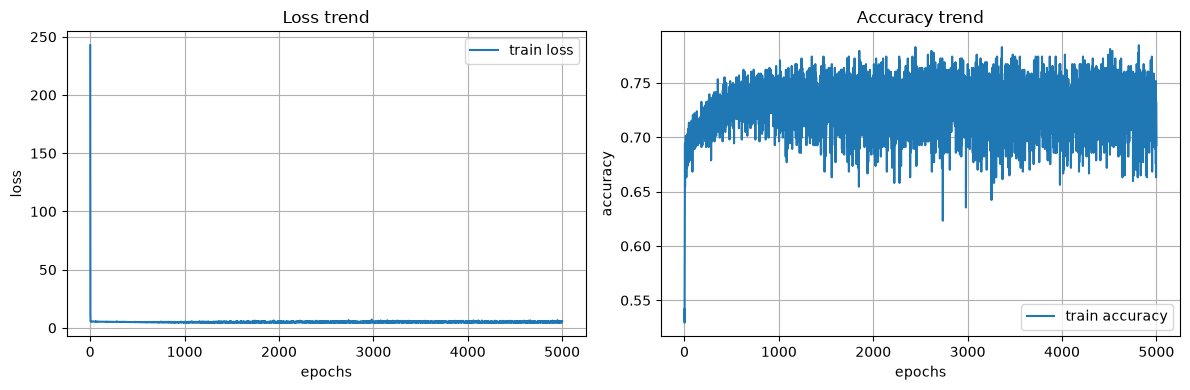

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.set_title('Loss trend')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.grid()
ax1.plot(train_loss_list, label='train loss')
ax1.legend(loc='best')

ax2.set_title('Accuracy trend')
ax2.set_xlabel('epochs')
ax2.set_ylabel('accuracy')
ax2.grid()
ax2.plot(train_accuracy_list, label='train accuracy')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()